# Capítulo 14 — Soluções dos exercícios complementares

**Curso de Meteorologia Prática** — baseado em R. Stull, *Practical Meteorology* (CC BY-NC-SA 4.0).

> **Para o professor.** Soluções dos teóricos **T1–T5** e numéricos **N1–N4** do Cap. 14. Não distribuir antes da entrega.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.integrate import solve_ivp
import metpy.calc as mpcalc
from metpy.units import units
import sys; sys.path.append('../comum')
from estilo_meteo import aplicar_estilo, CORES
aplicar_estilo()

g = 9.8

## T1 — $w_{max} = \sqrt{2\,CAPE}$

**Solução.** O empuxo por unidade de massa é $B = g(T_{v,p}-T_{v,e})/T_{v,e}$ (Cap. 5). O trabalho realizado sobre a parcela do LFC ao EL é
$$\int_{LFC}^{EL} B\,dz \equiv \mathrm{CAPE}.$$
Sem atrito nem entranhamento, o teorema trabalho–energia dá $\tfrac12 w_{EL}^2 - \tfrac12 w_{LFC}^2 = \mathrm{CAPE}$; com $w_{LFC} \approx 0$, $w_{max} = \sqrt{2\,\mathrm{CAPE}}$. É rigorosamente o mesmo cálculo do termal do Cap. 5, agora com a área inteira do Skew-T. ∎

## T2 — CAPE do triângulo

In [2]:
# excesso de temperatura triangular: dT(z) = dT_max * (z-LFC)/(z_m-LFC) até z_m,
# depois cai linear até EL. CAPE = g/T * área do triângulo = g dT_max (EL-LFC)/(2T)
z, zL, zE, zm, dTm, T_ = sp.symbols('z z_LFC z_EL z_m dT_max T', positive=True)
sobe = dTm*(z - zL)/(zm - zL)
desce = dTm*(zE - z)/(zE - zm)
cape = sp.integrate(g/T_*sobe, (z, zL, zm)) + sp.integrate(g/T_*desce, (z, zm, zE))
cape = sp.simplify(cape)
display(sp.Eq(sp.Symbol('CAPE'), cape))
val = cape.subs({dTm: 4.0, zE - zL: 10e3, T_: 260.0, zL: 2e3, zE: 12e3, zm: 7e3})
print(f'dT_max = 4 K numa camada de 10 km: CAPE = {float(val):.0f} J/kg —')
print('a área do Skew-T vira fórmula de bolso: CAPE ≈ g·dT_max·D/(2T).')

Eq(CAPE, 4.9*dT_max*(z_EL - z_LFC)/T)

dT_max = 4 K numa camada de 10 km: CAPE = 754 J/kg —
a área do Skew-T vira fórmula de bolso: CAPE ≈ g·dT_max·D/(2T).


## T3 — Entranhamento dilui

**Solução.** Misturando uma fração $\mu\,dz$ de ar ambiente por metro de subida, o excesso de qualquer propriedade conservada da parcela decai como $d(\Delta\phi)/dz = -\mu\,\Delta\phi$. Para o empuxo: $B(z) = B_{ad}(z)\,e^{-\mu z}$ aproximadamente, e o trabalho integrado (o CAPE efetivo) encolhe pelo mesmo fator médio. Com $\mu = 0{,}5/H_{ent}$ e $H_{ent}\sim$ raio da nuvem: torres LARGAS (Cb de 10 km) protegem o núcleo e realizam quase todo o CAPE; cumulus estreitos morrem diluídos — por isso o tamanho importa e por que o $w$ observado fica em $\sim w_{max}/2$. ∎ (N2 quantifica.)

## T4 — Corrente de densidade

**Solução (Benjamin).** Piscina fria de profundidade $H$ e déficit $\Delta\theta_v$ avançando em ar parado: no referencial da frente, Bernoulli ao longo da linha de corrente de estagnação + balanço hidrostático dos dois lados dão
$$c = k\sqrt{g' H},\qquad g' = g\,\frac{\Delta\theta_v}{\theta_v},$$
com $k = \sqrt{2}$ no caso ideal sem mistura ($k$ observado: 0,7–1,5·$\sqrt{g'H}$... a turbulência da cabeça da corrente cobra). Com $\Delta\theta_v = 5$ K e $H = 1$ km: $c \simeq \sqrt{2\cdot 9{,}8\cdot 1000\cdot 5/300} \simeq 18$ m/s — rajada de 65 km/h. ∎

## T5 — Número de Richardson volumétrico (BRN)

In [3]:
# BRN = CAPE / (0.5 * dU^2), dU = cisalhamento 0-6 km efetivo
print('BRN = CAPE/(dU²/2): razão entre a energia térmica disponível e a')
print('energia cinética do cisalhamento que organiza a tempestade.')
print()
for cape, du in [(2000, 8), (2000, 18), (2000, 35), (800, 18)]:
    brn = cape/(0.5*du**2)
    tipo = ('multicélula/supercélula' if 10 <= brn <= 50 else
            'célula única (shear fraco demais)' if brn > 50 else
            'cisalhamento rasga a convecção')
    print(f'CAPE = {cape:4d}, dU = {du:2d} m/s: BRN = {brn:5.0f} -> {tipo}')
print()
print('supercélulas vivem na faixa BRN ~ 10-50: energia E organização.')

BRN = CAPE/(dU²/2): razão entre a energia térmica disponível e a
energia cinética do cisalhamento que organiza a tempestade.

CAPE = 2000, dU =  8 m/s: BRN =    62 -> célula única (shear fraco demais)
CAPE = 2000, dU = 18 m/s: BRN =    12 -> multicélula/supercélula
CAPE = 2000, dU = 35 m/s: BRN =     3 -> cisalhamento rasga a convecção
CAPE =  800, dU = 18 m/s: BRN =     5 -> cisalhamento rasga a convecção

supercélulas vivem na faixa BRN ~ 10-50: energia E organização.


---
## N1 — Esquentando a tarde: quando a tampa estoura

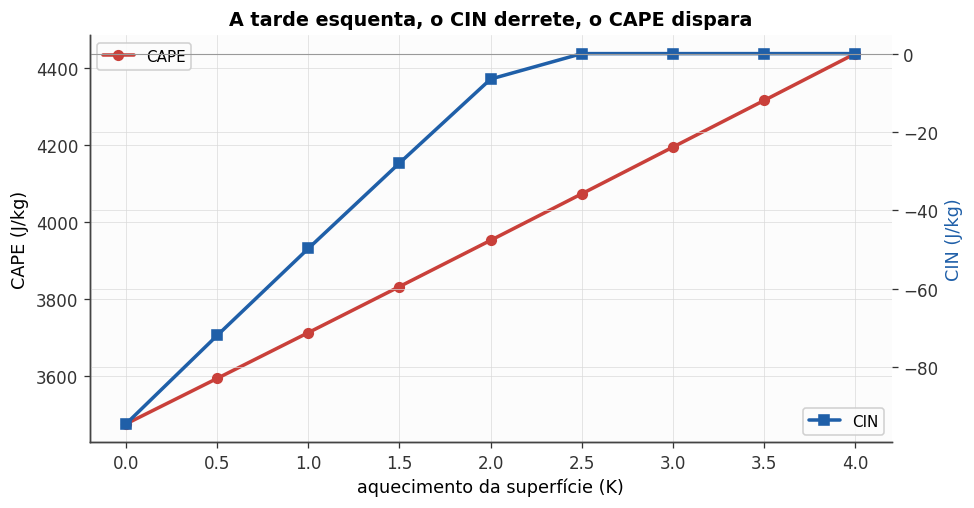

CIN ~ 0 com aquecimento de ~2.5 K: a hora da convecção
explosiva e meio da tarde — o maximo de T da marcha diurna (Cap. 3).


In [4]:
p = np.array([1000, 975, 950, 925, 900, 850, 800, 750, 700, 650, 600, 550,
              500, 450, 400, 350, 300, 250, 200, 150])*units.hPa
T0 = np.array([31, 29, 27.4, 25.8, 24.6, 22.5, 19, 15.5, 12, 8, 4, -0.5,
               -6, -12, -19, -27.5, -37, -47.5, -55, -62])
Td = np.array([23, 22.4, 21.8, 21.2, 19.5, 15, 11, 8, 4, -2, -8, -14,
               -20, -26, -33, -41, -50, -60, -70, -80])*units.degC

aquecs = np.arange(0, 4.5, 0.5)
capes, cins = [], []
for dq in aquecs:
    T = T0.copy(); T[0] += dq                # aquece só a superfície
    Tq = T*units.degC
    prof = mpcalc.parcel_profile(p, Tq[0], Td[0]).to('degC')
    cape, cin = mpcalc.cape_cin(p, Tq, Td, prof)
    capes.append(cape.m); cins.append(cin.m)

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.plot(aquecs, capes, 'o-', color=CORES['vermelho'], label='CAPE')
ax2 = ax.twinx()
ax2.plot(aquecs, cins, 's-', color=CORES['azul'], label='CIN')
ax2.axhline(0, color='#999999', lw=0.7)
ax.set(xlabel='aquecimento da superfície (K)', ylabel='CAPE (J/kg)',
       title='A tarde esquenta, o CIN derrete, o CAPE dispara')
ax2.set_ylabel('CIN (J/kg)', color=CORES['azul'])
ax.legend(loc='upper left'); ax2.legend(loc='lower right')
plt.show()
i = np.argmax(np.array(cins) > -5)
print(f'CIN ~ 0 com aquecimento de ~{aquecs[i]:.1f} K: a hora da convecção')
print('explosiva e meio da tarde — o maximo de T da marcha diurna (Cap. 3).')

## N2 — Updraft com entranhamento

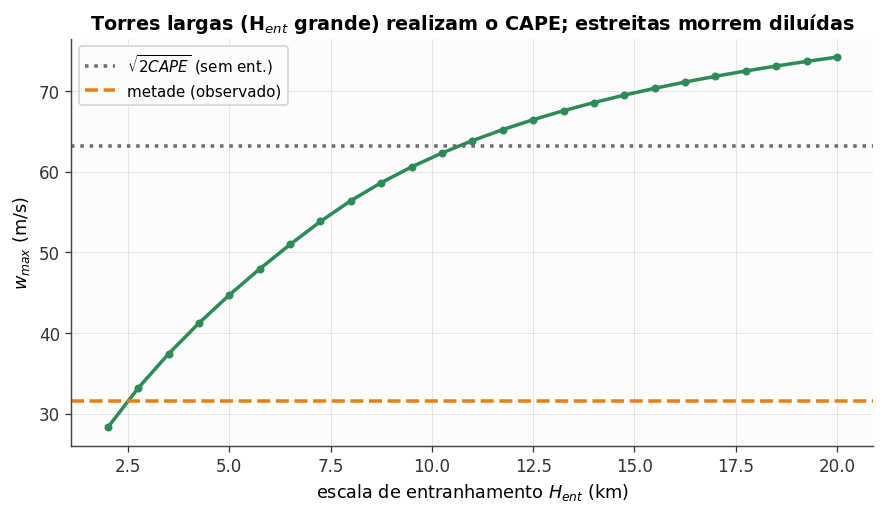

H_ent ~ 4-6 km ja reproduz o fator ~1/2 observado — consistente com
nucleos de Cb de alguns km protegidos por seu proprio tamanho.


In [5]:
CAPE, D = 2000.0, 10e3                        # J/kg, profundidade LFC->EL
B0 = 2*CAPE/D                                 # empuxo médio triangular ~const

def w_max_com_ent(H_ent):
    mu = 0.5/H_ent
    def rhs(z, y):
        w = max(y[0], 0.1)
        B = B0*np.exp(-mu*z)                  # diluição exponencial (T3)
        return [(B - mu*w**2)/w]
    s = solve_ivp(rhs, [0, D], [0.5], dense_output=True, rtol=1e-8)
    zz = np.linspace(0, D, 300)
    return np.max(s.sol(zz)[0])

Hs = np.linspace(2e3, 20e3, 25)
wm = [w_max_com_ent(H) for H in Hs]
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.plot(Hs/1e3, wm, 'o-', ms=4, color=CORES['verde'])
ax.axhline(np.sqrt(2*CAPE), color=CORES['cinza'], ls=':', label='$\\sqrt{2CAPE}$ (sem ent.)')
ax.axhline(np.sqrt(2*CAPE)/2, color=CORES['laranja'], ls='--', label='metade (observado)')
ax.set(xlabel='escala de entranhamento $H_{ent}$ (km)', ylabel='$w_{max}$ (m/s)',
       title='Torres largas (H$_{ent}$ grande) realizam o CAPE; estreitas morrem diluídas')
ax.legend()
plt.show()
print('H_ent ~ 4-6 km ja reproduz o fator ~1/2 observado — consistente com')
print('nucleos de Cb de alguns km protegidos por seu proprio tamanho.')

## N3 — Helicidade relativa à tempestade

In [6]:
z = np.linspace(0, 8000, 33)
u1 = 4*z/8000;  v1 = 1*z/8000
u2 = 24*z/8000; v2 = 3*z/8000
ang = np.pi/2*(1 - np.exp(-z/2500))
u3 = 22*np.sin(ang); v3 = -22*(1 - np.cos(ang))

def srh(u, v, z, z_top=3000.0):
    m = z <= 6000
    um, vm = u[m].mean(), v[m].mean()          # vento médio 0-6 km
    # movimento: 75% do médio, desviado 30° À ESQUERDA (HS)
    ang_d = np.deg2rad(30)
    cu = 0.75*(um*np.cos(ang_d) + vm*np.sin(ang_d))
    cv = 0.75*(-um*np.sin(ang_d) + vm*np.cos(ang_d))
    m3 = z <= z_top
    ur, vr = u[m3] - cu, v[m3] - cv
    return np.sum(ur[:-1]*np.diff(v[m3]) - vr[:-1]*np.diff(u[m3]))

for (u, v), nome in [((u1, v1), 'fraco'), ((u2, v2), 'reto forte'),
                      ((u3, v3), 'curvo forte')]:
    print(f'{nome:12s}: SRH(0-3 km) = {srh(u, v, z):7.1f} m²/s²')
print()
print('|SRH| > 150 m²/s² marca ambiente de supercelula: so o hodografo CURVO')
print('entrega — cisalhamento reto da multicelulas por mais forte que seja.')
print('(No HS a helicidade util e POSITIVA para mesociclones horarios.)')

fraco       : SRH(0-3 km) =    -0.9 m²/s²
reto forte  : SRH(0-3 km) =   -30.8 m²/s²
curvo forte : SRH(0-3 km) =  -276.1 m²/s²

|SRH| > 150 m²/s² marca ambiente de supercelula: so o hodografo CURVO
entrega — cisalhamento reto da multicelulas por mais forte que seja.
(No HS a helicidade util e POSITIVA para mesociclones horarios.)


## N4 — Equilíbrio RKW

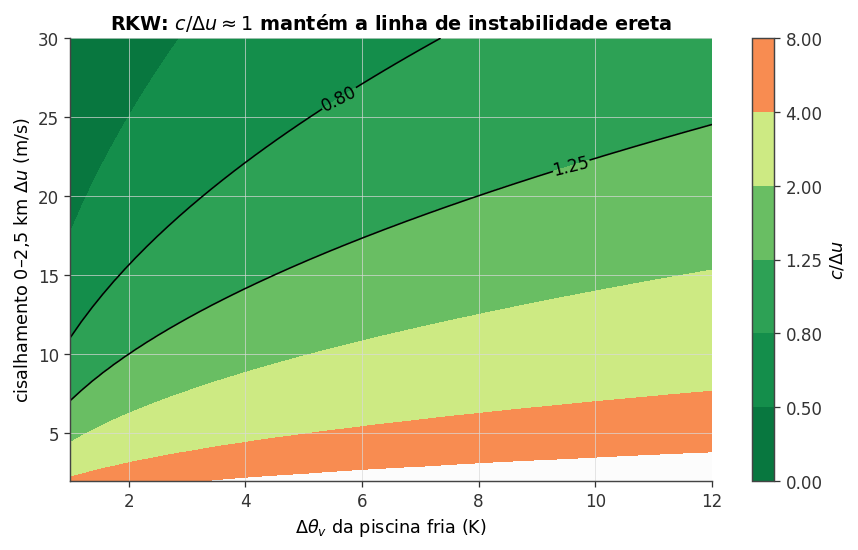

c/du >> 1: a piscina fria dispara na frente e corta o updraft (linha morre);
c/du << 1: o cisalhamento deita a corrente; ~1: gatilho continuo na frente
de rajada — linhas duradouras precisam de piscina E cisalhamento casados.


In [7]:
theta0 = 300.0
dths = np.linspace(1, 12, 60)
dus = np.linspace(2, 30, 60)
DTH, DU = np.meshgrid(dths, dus)
H = 1200.0
C = np.sqrt(2*g*H*DTH/theta0)
razao = C/DU

fig, ax = plt.subplots(figsize=(9, 5))
cf = ax.contourf(DTH, DU, razao, levels=[0, 0.5, 0.8, 1.25, 2, 4, 8],
                 cmap='RdYlGn_r')
cs = ax.contour(DTH, DU, razao, levels=[0.8, 1.25], colors='k', linewidths=1)
ax.clabel(cs, fmt='%.2f')
ax.set(xlabel='$\\Delta\\theta_v$ da piscina fria (K)',
       ylabel='cisalhamento 0–2,5 km $\\Delta u$ (m/s)',
       title='RKW: $c/\\Delta u \\approx 1$ mantém a linha de instabilidade ereta')
fig.colorbar(cf, label='$c/\\Delta u$')
plt.show()
print('c/du >> 1: a piscina fria dispara na frente e corta o updraft (linha morre);')
print('c/du << 1: o cisalhamento deita a corrente; ~1: gatilho continuo na frente')
print('de rajada — linhas duradouras precisam de piscina E cisalhamento casados.')

---
*Material derivado de R. Stull, Practical Meteorology (CC BY-NC-SA 4.0); este notebook herda a mesma licença.*